<a href="https://colab.research.google.com/github/Somalin2004/Celebal_internship/blob/main/week4_somalin_samal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3374s 20us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## 🖼️ Visualize Sample Images

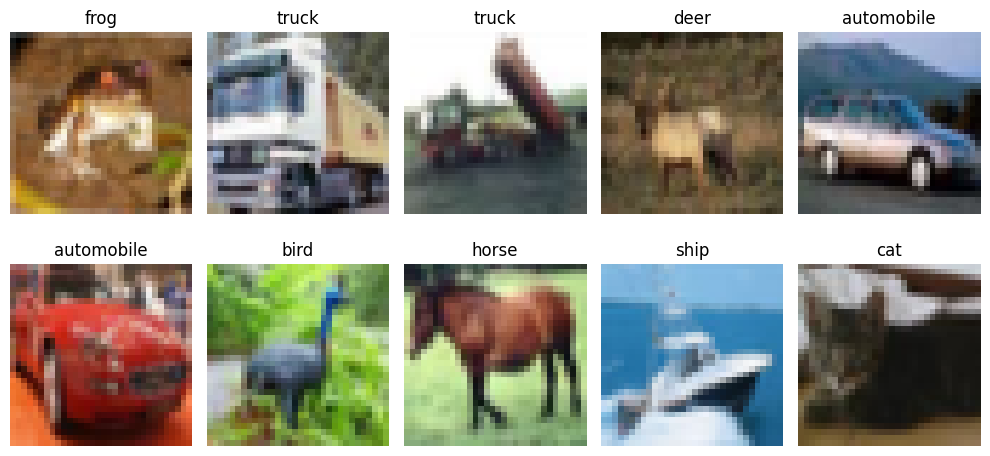

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.2680 - loss: 2.0060 - val_accuracy: 0.3338 - val_loss: 1.8356
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 29ms/step - accuracy: 0.3186 - loss: 1.8650 - val_accuracy: 0.3698 - val_loss: 1.7956
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3350 - loss: 1.8254 - val_accuracy: 0.3756 - val_loss: 1.7653
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3506 - loss: 1.7895 - val_accuracy: 0.3980 - val_loss: 1.7288
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.3565 - loss: 1.7689 - val_accuracy: 0.3898 - val_loss: 1.7068
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3689 - loss: 1.7397 - val_accuracy: 0.3960 - val_loss: 1.6977
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3736 - loss: 1.7246 - val_accuracy: 0.3868 - val_loss: 1.7089
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3820 - loss: 1.7085 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4055 - loss: 1.7040
ANN Test Accuracy: 0.40549999475479126


increase ann size ,epochs and analyse


In [9]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.2169 - loss: 2.0773 - val_accuracy: 0.2838 - val_loss: 1.9322
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.2776 - loss: 1.9387 - val_accuracy: 0.3240 - val_loss: 1.8674
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.2971 - loss: 1.8955 - val_accuracy: 0.3272 - val_loss: 1.8736
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3107 - loss: 1.8601 - val_accuracy: 0.3460 - val_loss: 1.8082
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3172 - loss: 1.8472 - val_accuracy: 0.3568 - val_loss: 1.8066
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.3288 - loss: 1.8302 - val_accuracy: 0.3494 - val_loss: 1.8222
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3310 - loss: 1.8140 - val_accuracy: 0.3744 - val_loss: 1.7599
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.3411 - loss: 1.7965 - 

In [10]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4001 - loss: 1.6962
ANN Test Accuracy: 0.4000999927520752


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 127ms/step - accuracy: 0.4718 - loss: 1.4817 - val_accuracy: 0.5064 - val_loss: 1.3613
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 126ms/step - accuracy: 0.6086 - loss: 1.1259 - val_accuracy: 0.5128 - val_loss: 1.4031
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 147s 133ms/step - accuracy: 0.6696 - loss: 0.9493 - val_accuracy: 0.6686 - val_loss: 0.9444
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 135ms/step - accuracy: 0.7091 - loss: 0.8348 - val_accuracy: 0.7164 - val_loss: 0.8348
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 137s 128ms/step - accuracy: 0.7378 - loss: 0.7504 - val_accuracy: 0.6872 - val_loss: 0.9081
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7695 - loss: 0.6646 - val_accuracy: 0.7236 - val_loss: 0.8211
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.7878 - loss: 0.5960 - val_accuracy: 0.6966 - val_loss: 0.9297
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.8092 - lo

In [12]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6582 - loss: 1.3057
CNN Test Accuracy: 0.6582000255584717


## 📈 Compare Learning Curves

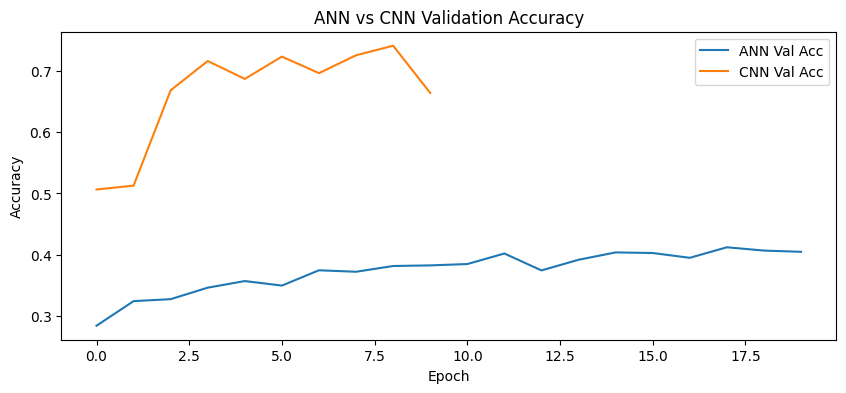

In [13]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=20, validation_split=0.1,batch_size=64)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 102ms/step - accuracy: 0.3567 - loss: 1.7733 - val_accuracy: 0.4926 - val_loss: 1.4183
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 102ms/step - accuracy: 0.4530 - loss: 1.5164 - val_accuracy: 0.5318 - val_loss: 1.3015
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 101ms/step - accuracy: 0.4930 - loss: 1.4186 - val_accuracy: 0.5544 - val_loss: 1.2220
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 101ms/step - accuracy: 0.5125 - loss: 1.3642 - val_accuracy: 0.5892 - val_loss: 1.1328
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 103ms/step - accuracy: 0.5284 - loss: 1.3171 - val_accuracy: 0.5744 - val_loss: 1.1599
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 104ms/step - accuracy: 0.5443 - loss: 1.2835 - val_accuracy: 0.6086 - val_loss: 1.0892
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - accuracy: 0.5577 - loss: 1.2496 - val_accuracy: 0.6238 - val_loss: 1.0618
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 100ms/step - accuracy: 0.5658 - loss: 1

In [15]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test,
    verbose=1
)

print("Augmented CNN Accuracy:", aug_test_acc)
print("Augmented CNN Loss:", aug_test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6675 - loss: 0.9487
Augmented CNN Accuracy: 0.6675000190734863
Augmented CNN Loss: 0.9487035870552063


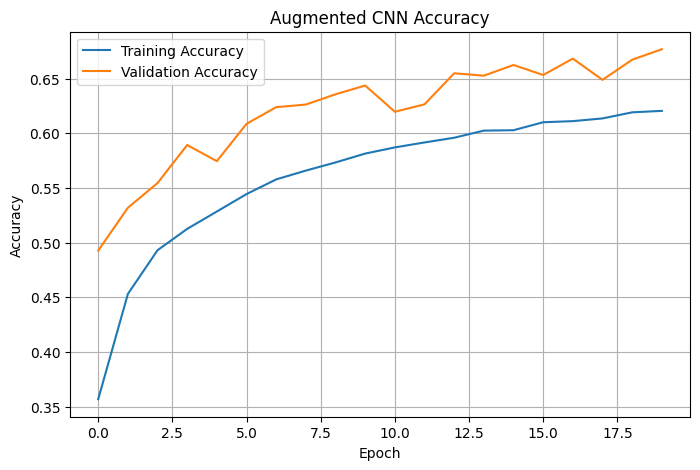

In [16]:
plt.figure(figsize=(8,5))

plt.plot(aug_history.history['accuracy'], label='Training Accuracy')
plt.plot(aug_history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Augmented CNN Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# 📊 Final Comparison Table

In [17]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4001
1,CNN,0.6582


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

# ✅ Conclusion final

- **ANN works**
- exp         change

- 1            defult  , -  test- accuracy = 0.41

- 2           epoch  - 20 ,  - test-accuracy = 0.44

- 3           add 1 layer - 128 , - test - accuracy = no change

- 4           add 1 layer - 128 or BatchNormalization()  ,- test- accuracy = 0.49


- **CNN works**
- exp           change
- 1             dafult  ,  - test accuracy = 0.70
- 2             epoch = 20 , - accuracy = 0.67
- 3             epoch = 10 , increase filter , - accuracy = 0.74
- 4             dropout increse to 0.5 , accuracy = 0.72
- 5              data augmentation , epoch 10 , accuracy = 0.62
- 6              data augmentation , epoch 20 , accuracy = 0.66